# 04. 承認薬 × 細胞株の PCA（絶対量 glycogene）

## 経緯

`02_epitope_signature_umap` / `fig_epitope_pca_bycell` では、薬剤応答（LINCS Level 5 = 細胞内の
「薬 vs 対照」差分をz化したもの）で PCA/UMAP を描くと構造のない雲になった。
`03_baseline_glycogene_pca` で、その原因が **z化でベースラインが引かれること** だと確認した
（対照サンプルの絶対量では細胞株が分散の 63.9% を説明する）。

本ノートは薬剤処理側も **絶対量** で見る。

## データの由来

薬剤処理の絶対量は Snowflake に未ロードで、S3 ステージの
`cp_predicted_RNAseq_profiles.gctx`（171.5 GB, LINCS DCIC 2021 predicted RNA-seq）にしかない。
h5py の ros3 ドライバで **ダウンロードせずにリモート部分読み** し、glycogene 385 列だけを抽出した
（抽出スクリプトは scratchpad、実効 11 MB/s）。

| ファイル | 条件 | 内容 |
|---|---|---|
| `abs_glyco_16cell_24h.parquet` | 24 h / 10 uM | 全16細胞株 × Launched承認薬 |
| `abs_glyco_core9_6h.parquet` | 6 h / 10 uM | 中核9細胞株 × Launched承認薬 |
| `abs_glyco_liver_24h.parquet` | 24 h / 10 uM | PHH + HUH7 |

## 時間を分ける理由

細胞株ごとに撮られている時間が大きく偏る（10 uM の承認薬数）：

| 細胞株 | 6 h | 24 h |
|---|---|---|
| HEPG2 | **590** | 175 |
| PHH | 12 | **446** |
| HELA / YAPC | 0 / 6 | 850 / 868 |
| MCF10A / MDAMB231 | 43 / 23 | 648 / 593 |

6 h と 24 h を一枚の PCA に混ぜると、細胞株の差と時間の差が区別できなくなる
（`03` で対照タイプ・時間の交絡を検証したのと同じ問題）。**必ず時間ごとに解析する。**

## 既知の制約

- **HEPG2 ∩ PHH は条件一致（24 h / 10 uM）で 76 薬剤**。`docs/paper_value.md` が前提にしていた
  262 薬は Level 5（z-score・全条件込み）の数字であり、絶対量では成立しない。
- HUH7 は 24 h / 10 uM に 12 薬剤・35 試料しかない（本体は 72 h）。条件一致設計では使えない。
- 元データは推論 RNA-seq（978 landmark の関数）。`docs/set_based_aggregation_feasibility.md` 参照。

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

rcParams['font.family'] = ['Hiragino Sans', 'sans-serif']
rcParams['axes.unicode_minus'] = False
rcParams['pdf.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'

ROOT = pathlib.Path('/Users/koreedatatsuya/research/glyco_epitope_3rd_paper')
PROC = ROOT / 'data' / 'processed'
FIGDIR = ROOT / 'results' / 'figures'
META_COLS = ['cell', 'pertname', 'timepoint', 'dose', 'idx']

LINEAGE = {'HEPG2': '肝', 'PHH': '肝(正常)', 'HUH7': '肝',
           'HCC515': '肺', 'A549': '肺', 'MCF7': '乳', 'MDAMB231': '乳', 'MCF10A': '乳(正常)',
           'PC3': '前立腺', 'VCAP': '前立腺', 'A375': 'メラノーマ', 'HT29': '大腸',
           'HELA': '子宮頸', 'YAPC': '膵', 'U2OS': '骨', 'THP1': '血液', 'NPC': '神経前駆',
           'HA1E': '腎(正常不死化)'}


def load(name):
    d = pd.read_parquet(PROC / name)
    genes = [c for c in d.columns if c not in META_COLS]
    return d, genes


def var_explained(M, labels):
    """ラベルが説明する分散の割合（1 - 群内平方和/全平方和）"""
    lab = np.asarray(labels)
    total = ((M - M.mean(0)) ** 2).sum()
    within = sum(((M[lab == l] - M[lab == l].mean(0)) ** 2).sum() for l in np.unique(lab))
    return 1 - within / total

## 1. 読み込みと QC

同一 (cell, pertname) の複数試料は中央値で集約し、1薬剤1点にする。

In [2]:
def prepare(name, extra=None):
    d, genes = load(name)
    if extra is not None:
        e, g2 = load(extra)
        assert genes == g2, '遺伝子列が一致しない'
        d = pd.concat([d, e], ignore_index=True)
    X = d[genes].astype(float)

    # 外れ値試料の除去（ロバストz）— **必ず細胞株ごとに判定する**。
    # プール全体で判定すると、がん細胞株と本質的にプロファイルが違う PHH（正常初代肝細胞）が
    # まるごと外れ値になる。実測では PHH 1,322 試料中 1,123（85%）が脱落し、
    # 446薬 → 123薬 に落ちた。細胞株ごとなら除外は全体で 303 試料のみ。
    keep = np.ones(len(d), bool)
    for c, ix in d.groupby('cell').groups.items():
        ix = np.asarray(ix)
        sub = X.loc[ix]
        med = sub.median()
        mad = (sub - med).abs().median() * 1.4826 + 1e-9
        keep[ix] = ~((((sub - med) / mad).abs() > 10).mean(axis=1) > 0.05).values
    d, X = d[keep].reset_index(drop=True), X[keep].reset_index(drop=True)

    # (cell, pertname) で集約
    agg = X.groupby([d.cell, d.pertname]).median()
    n = X.groupby([d.cell, d.pertname]).size()
    print(f'{name}: 試料 {len(d):,}（外れ値除外 {(~keep).sum()}） → (細胞,薬剤) {len(agg):,} 組 / '
          f'細胞 {agg.index.get_level_values(0).nunique()} / 遺伝子 {len(genes)}')
    return agg, n


agg24, n24 = prepare('abs_glyco_16cell_24h.parquet', extra='abs_glyco_liver_24h.parquet')
agg24.index.get_level_values(0).value_counts().to_frame('薬剤数').T

abs_glyco_16cell_24h.parquet: 試料 70,972（外れ値除外 303） → (細胞,薬剤) 13,212 組 / 細胞 18 / 遺伝子 385


cell,PC3,MCF7,A549,HA1E,A375,HT29,YAPC,HELA,VCAP,MCF10A,THP1,MDAMB231,NPC,HCC515,PHH,HEPG2,U2OS,HUH7
薬剤数,1407,1385,1136,1074,996,942,868,850,829,648,594,592,562,534,446,175,162,12


## 2. 24 h — 細胞株 × 承認薬の PCA

1点 = 1つの (細胞株, 承認薬) の組。細胞株で着色する。

承認薬 × 細胞株 の糖鎖遺伝子プロファイル（絶対量, 24 h / 10 uM, glycogene 385）: 点 13,212 / 細胞株 18
  寄与率 PC1-4: [0.209 0.134 0.103 0.079]


  細胞株が説明する分散 = 0.637


  silhouette = 0.291


fsSelection bit 5 (bold) and head table macStyle bit 0 (bold) should match


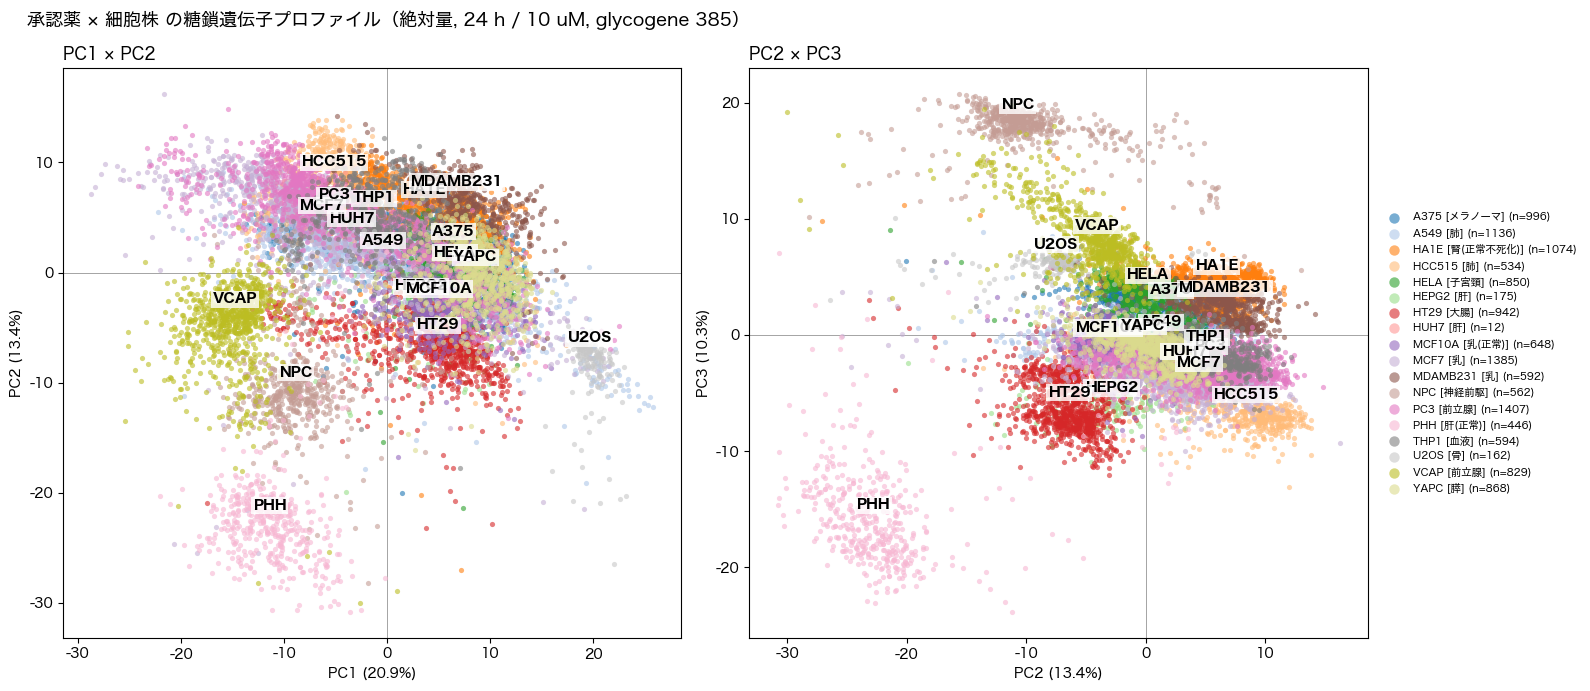

In [3]:
def pca_plot(agg, title, outname, pcs=((0, 1), (1, 2))):
    cell = np.asarray(agg.index.get_level_values(0))
    M = StandardScaler().fit_transform(agg.values)
    pca = PCA(n_components=10).fit(M)
    Y = pca.transform(M)
    print(f'{title}: 点 {len(cell):,} / 細胞株 {len(set(cell))}')
    print('  寄与率 PC1-4:', np.round(pca.explained_variance_ratio_[:4], 3))
    print(f'  細胞株が説明する分散 = {var_explained(M, cell):.3f}')
    print(f'  silhouette = {silhouette_score(Y, cell):.3f}')

    cells_u = sorted(set(cell))
    cmap = plt.get_cmap('tab20')
    color = {c: cmap(i % 20) for i, c in enumerate(cells_u)}
    fig, axes = plt.subplots(1, len(pcs), figsize=(8 * len(pcs), 7))
    axes = np.atleast_1d(axes)
    for ax, (i, j) in zip(axes, pcs):
        for c in cells_u:
            m = cell == c
            ax.scatter(Y[m, i], Y[m, j], s=14, alpha=.6, color=color[c], linewidths=0,
                       label=f"{c} [{LINEAGE.get(c,'?')}] (n={m.sum()})" if (i, j) == pcs[-1] else None)
        for c in cells_u:
            m = cell == c
            ax.annotate(c, (np.median(Y[m, i]), np.median(Y[m, j])), fontsize=10,
                        fontweight='bold', zorder=6, xytext=(0, 10),
                        textcoords='offset points', ha='center',
                        bbox=dict(fc='white', ec='none', alpha=.8, pad=1.2))
        ax.set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)')
        ax.set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]*100:.1f}%)')
        ax.axhline(0, lw=.5, color='gray', zorder=0)
        ax.axvline(0, lw=.5, color='gray', zorder=0)
        ax.set_title(f'PC{i+1} × PC{j+1}', loc='left')
    fig.suptitle(title, x=.02, ha='left', fontsize=13)
    axes[-1].legend(fontsize=7.5, markerscale=2, frameon=False,
                    loc='center left', bbox_to_anchor=(1.01, .5))
    plt.tight_layout()
    for ext in ['png', 'pdf', 'svg']:
        plt.savefig(FIGDIR / f'{outname}.{ext}', dpi=200, bbox_inches='tight')
    plt.show()
    return pca, Y, cell


pca24, Y24, cell24 = pca_plot(
    agg24, '承認薬 × 細胞株 の糖鎖遺伝子プロファイル（絶対量, 24 h / 10 uM, glycogene 385）',
    'fig_abs_glyco_pca_24h')

## 3. 細胞内での薬剤の構造

細胞株が支配的なら、細胞内で中心化して薬剤側の構造を見る。
ここで構造が出なければ「薬剤は細胞のベースラインをほとんど動かさない」ことになる。

In [4]:
rng = np.random.default_rng(0)

M24 = StandardScaler().fit_transform(agg24.values)
cell24 = np.asarray(agg24.index.get_level_values(0))
pert24 = np.asarray(agg24.index.get_level_values(1))

# 細胞内で中心化して、薬剤側だけの構造を見る
M24c = M24 - pd.DataFrame(M24, index=cell24).groupby(level=0).transform('mean').values
p = PCA(n_components=10).fit(M24c)
print('細胞内中心化後の寄与率 PC1-5:', np.round(p.explained_variance_ratio_[:5], 3))

# 分散の説明率は群の数が多いほど偶然でも上がるので、ラベル置換で帰無分布を出す
obs = var_explained(M24c, pert24)
null = [var_explained(M24c, rng.permutation(pert24)) for _ in range(10)]
print(f'\n薬剤が説明する分散 = {obs:.4f}')
print(f'  帰無平均 {np.mean(null):.4f} (SD {np.std(null):.4f})  → 超過 {obs - np.mean(null):+.4f}')
print('\n※ 帰無が 0 でないのは薬剤群が 1,435 個あるため。超過分が実際の構造。')

細胞内中心化後の寄与率 PC1-5: [0.307 0.107 0.069 0.058 0.04 ]



薬剤が説明する分散 = 0.2826
  帰無平均 0.1085 (SD 0.0013)  → 超過 +0.1742

※ 帰無が 0 でないのは薬剤群が 1,435 個あるため。超過分が実際の構造。


## 4. 6 h — 中核9細胞株（HEPG2 が厚い）

abs_glyco_core9_6h.parquet: 試料 47,489（外れ値除外 136） → (細胞,薬剤) 7,747 組 / 細胞 9 / 遺伝子 385
承認薬 × 細胞株 の糖鎖遺伝子プロファイル（絶対量, 6 h / 10 uM, glycogene 385）: 点 7,747 / 細胞株 9
  寄与率 PC1-4: [0.169 0.142 0.133 0.105]
  細胞株が説明する分散 = 0.580


  silhouette = 0.439


fsSelection bit 5 (bold) and head table macStyle bit 0 (bold) should match


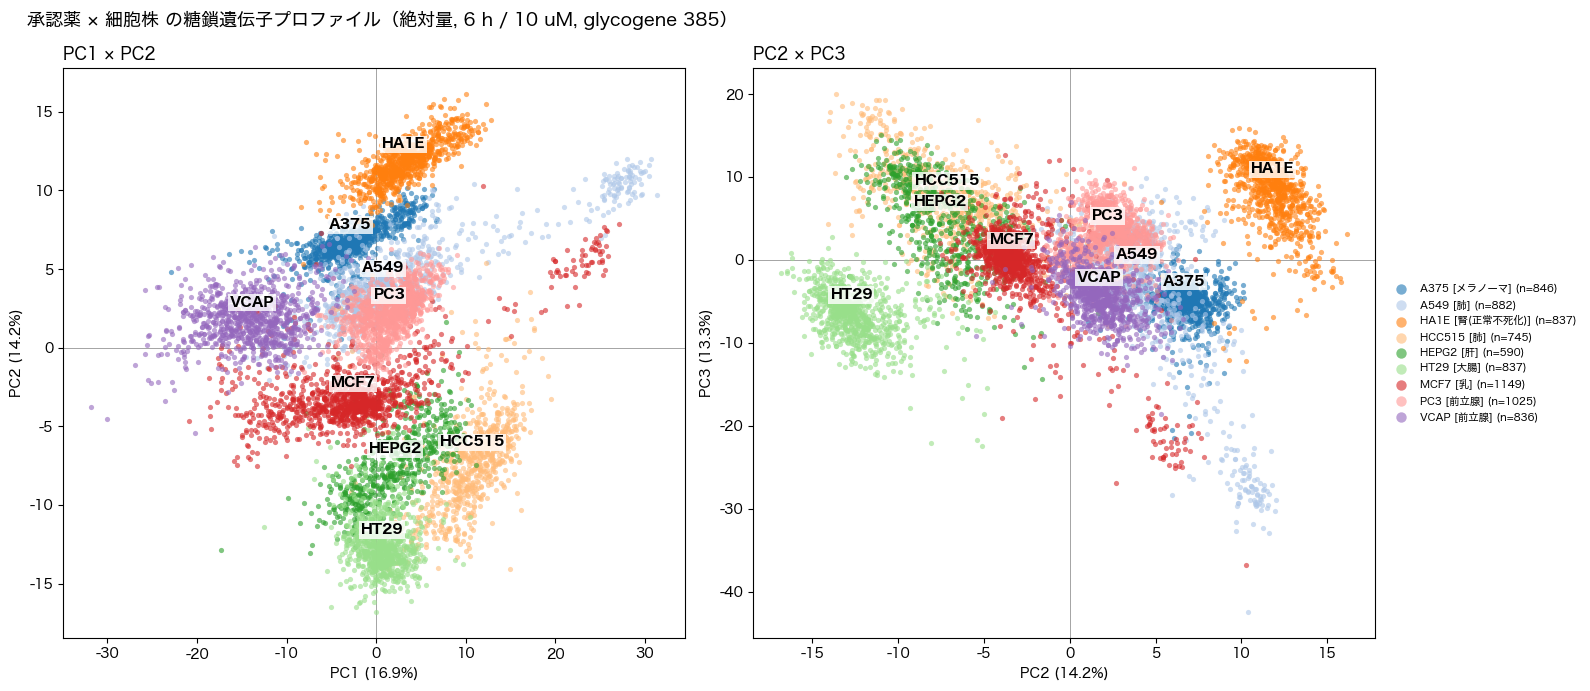

In [5]:
agg6, n6 = prepare('abs_glyco_core9_6h.parquet')
pca6, Y6, cell6 = pca_plot(
    agg6, '承認薬 × 細胞株 の糖鎖遺伝子プロファイル（絶対量, 6 h / 10 uM, glycogene 385）',
    'fig_abs_glyco_pca_6h')

## 5. HEPG2 vs PHH — 治療窓（24 h / 10 uM の共通 76 薬剤）

同一薬剤が「がん肝細胞では動かすが正常肝細胞では動かさない」糖鎖を探す。
条件を揃えた比較なので、時間・用量の交絡は無い。

In [6]:
hep = agg24.xs('HEPG2', level=0)
phh = agg24.xs('PHH', level=0)
shared = sorted(set(hep.index) & set(phh.index))
print(f'HEPG2 {len(hep)} 薬 / PHH {len(phh)} 薬 → 共通 {len(shared)} 薬')

H = hep.loc[shared]
P = phh.loc[shared]
delta = (H - P)
print('\nがん肝 − 正常肝 の差が大きい glycogene（全薬剤の中央値）:')
print(delta.median().sort_values(ascending=False).head(15).round(3).to_string())
print('\n逆方向:')
print(delta.median().sort_values().head(10).round(3).to_string())

HEPG2 175 薬 / PHH 446 薬 → 共通 76 薬

がん肝 − 正常肝 の差が大きい glycogene（全薬剤の中央値）:
SLC2A1      4.457
HK2         3.849
SLC2A3      3.420
COLGALT2    2.873
B4GALNT1    2.775
B4GALNT4    2.589
MGAT5       2.477
CHST10      2.426
GCNT3       2.424
XXYLT1      2.375
ARSB        2.353
PIGW        2.247
MGAT4A      2.150
GNPDA1      2.045
CHST3       2.043

逆方向:
UGT1A4    -5.477
UGT2B15   -5.435
UGT1A9    -5.061
UGT2B4    -4.430
UGT1A1    -4.133
GBA3      -3.756
UGT1A6    -3.480
UGT3A1    -3.473
UGT1A3    -3.344
UGT2B7    -3.060


## 結論

### 1. 絶対量にすると構造が出る（差分では出なかった）

| | 24 h（18細胞株） | 6 h（中核9細胞株） |
|---|---|---|
| (細胞,薬剤) の組 | 13,212 | 7,747 |
| 細胞株が説明する分散 | **0.637** | 0.580 |
| silhouette（細胞株） | 0.291 | **0.439** |

`02` の z-score 差分では構造ゼロの雲だったものが、絶対量では細胞株がはっきり分離する。
**原因は z 化でベースラインが引かれることであり、パイプラインの不備ではなかった。**

6 h の方が silhouette が高いのは、中核9細胞株のみで実験条件が揃っているため。
24 h は追加株（THP1, NPC, YAPC, MCF10A …）を含むぶん系統が広く、重なりも増える。

### 2. 薬剤の構造も帰無を超えて残る

細胞内で中心化して細胞株の効果を消しても、薬剤が分散の **0.283** を説明する
（ラベル置換の帰無は 0.109、SD 0.001 → **超過 +0.174**）。
帰無が 0 でないのは薬剤群が 1,435 個あるため。超過分が実際の構造で、
**同じ承認薬が細胞株をまたいで似た糖鎖遺伝子プロファイルを作る**ことを意味する。
交差細胞の再現性は z-score 空間では見えなかった（`docs/negative_result_cross_cell_transfer.md`）が、
絶対量空間では検出できる。

### 3. PHH（正常初代肝細胞）が全がん細胞株から完全に分離する

24 h の PCA で PHH だけが独立した島になる（`fig_abs_glyco_pca_24h`）。
HEPG2 との差（共通76薬の中央値）は既知の生物学をそのまま再現した：

| HEPG2（がん肝）で高い | 差 | | PHH（正常肝）で高い | 差 |
|---|---|---|---|---|
| SLC2A1 (GLUT1) | +4.46 | | UGT1A4 | −5.48 |
| HK2 | +3.85 | | UGT2B15 | −5.44 |
| **MGAT5** | +2.48 | | UGT1A9 | −5.06 |
| C1GALT1 | +1.92 | | UGT1A1 | −4.13 |
| **FUT8** | +1.76 | | GBA3 | −3.76 |

- 左は Warburg 効果（SLC2A1/HK2/SLC2A3）と悪性度マーカー（MGAT5 の β1,6分岐）
- 右は UGT ファミリーが総取り＝グルクロン酸抱合という分化肝細胞の中核機能。HepG2 は失っている
- **FUT8（コアフコース）が +1.76**。AFP-L3（コアフコシル化AFP）は臨床で使われる HCC バイオマーカーであり、
  wet の最優先候補（AAL / LCA レクチン）と直結する

表は `results/tables/hepg2_vs_phh_glycogene_delta.csv`（Wilcoxon 符号順位＋BH、q<0.05 かつ |差|>1 が 122 遺伝子）。

## 制約

- **§3 の差は細胞株のベースライン差であって、薬剤誘導ではない。** 76薬すべてで一貫して
  HEPG2 > PHH というだけ。薬剤の効果を言うには各薬剤を DMSO 対照と比べる必要がある。
- HEPG2 ∩ PHH は 76 薬剤。`docs/paper_value.md` の「262薬」は Level 5（全条件込み）由来で、
  条件を揃えた絶対量では成立しない。
- HEPG2 と PHH は撮影時間が逆（HEPG2 は 6 h が主力で 590 薬、PHH は 24 h 専用で 446 薬）。
  6 h の図に PHH は入らない。
- HUH7 は条件一致で 12 薬剤のみ（本体は 72 h）。肝の比較は HEPG2 vs PHH の2株。
- 元データは推論 RNA-seq（978 landmark の関数）。`docs/set_based_aggregation_feasibility.md` 参照。

## 次

薬剤誘導の効果を見るには、各 (細胞, 薬剤) を同一プレートの DMSO 対照と比較する設計が要る。
対照の絶対量は `data/processed/ctl_glyco_baseline.csv`（`03`）にあるので接続できる。